# **1. Import Libraries**

In [1]:
!pip install xgboost


In [2]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


In [4]:
import os
print(os.listdir())


['.config', 'xGboost_mdoel.pk1', 'model_training.ipynb', 'processed_nvidia.csv', 'scaler.pk1', 'sample_data']


# **2. Load Model and Scaler**

In [5]:
model = joblib.load("xGboost_mdoel.pk1")
scaler = joblib.load("scaler.pk1")


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# **3. Load Dataset**

In [6]:
test_data = pd.read_csv("processed_nvidia.csv")
print(test_data.head())


         Date       Open       High        Low      Close  Adj Close  \
0  2019-08-02  40.297501  40.994999  39.820000  40.297501  40.069515   
1  2019-08-05  38.450001  38.462502  37.224998  37.697498  37.484203   
2  2019-08-06  38.450001  38.907501  37.607498  38.087502  37.872009   
3  2019-08-07  37.474998  38.592499  37.299999  38.472500  38.254829   
4  2019-08-08  39.052502  39.577499  38.474998  39.564999  39.341145   

     Volume       MA10      MA50    Return    Target  volatility       Lag1  \
0  42834800  42.979751  39.32900 -0.022617 -0.064520    0.022426  41.230000   
1  58915600  42.466501  39.34635 -0.064520  0.010346    0.027990  40.297501   
2  36127200  41.883751  39.38235  0.010346  0.010108    0.026087  37.697498   
3  37256000  41.264500  39.43515  0.010108  0.028397    0.025249  38.087502   
4  30930000  40.886500  39.52475  0.028397 -0.025780    0.027923  38.472500   

        Lag2       Lag3  
0  42.180000  43.862499  
1  41.230000  42.180000  
2  40.297501  

# **4. Data Preparation**
Drop Date Column

In [7]:
data = pd.read_csv("processed_nvidia.csv")

data = data.drop("Date", axis=1)


Separate Features and Target

In [8]:
X = data.drop("Target", axis=1)
y = data["Target"]


Time based split

In [9]:
split_index = int(len(data) * 0.8)

X_test = X[split_index:]
y_test = y[split_index:]


# **5. Apply Scaling**

In [10]:
X_test_scaled = scaler.transform(X_test)


# **6. Model Prediction**

In [11]:
y_pred = model.predict(X_test_scaled)


# **7. Model Evaluation**

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)


MSE: 0.0013688999536763053
RMSE: 0.036998647997951294
MAE: 0.029305047846540446


**Model Evaluation Summary:**

The RMSE value of 0.0369 indicates that the average deviation between predicted and actual return values is relatively small. The MAE of 0.0293 suggests the model predictions are reasonably close to actual market movements. Overall, the model captures short term return patterns with moderate accuracy.

# **8. Visualization**

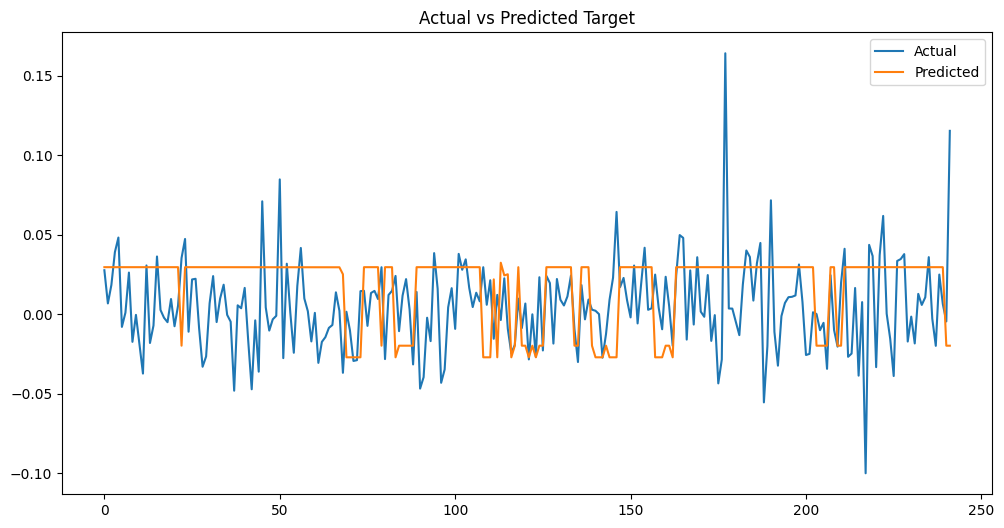

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Target")
plt.show()


**The RMSE value indicates the average prediction error magnitude. The model captures overall trend movement but struggles during high volatility periods.**